<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Beyond the Fundamental: A Spectral Adventure </b></h3>

**Автор**: Ермекова Асель

*P.S.* *На русском перевод емкого и классного названия не получился у меня. Если у вас есть идеи как назвать эту домашку прикольно, пишите в чатике в телеграме ваши предложения русского варианта названия домашки!*

## задание

**Что делает скрипку похожей на скрипку?**

Вы когда-нибудь задумывались, почему скрипка, флейта и гитара звучат совершенно по-разному, даже играя одну и ту же ноту на одинаковой громкости?

Ответ кроется в фундаментальном свойстве звука, называемом тембром. Тембр — это «цвет» или «текстура» звука — то, что позволяет вам мгновенно отличить трубу от фортепиано или голос вашего друга от голоса незнакомца, даже если они поют в одной тональности.

**Но что физически создаёт тембр?**

Всё сводится к гармоникам — смеси частот, сопровождающих основной тон, — и тому, как их амплитуды и фазы изменяются с течением времени. Два инструмента, играющие ноту Ля или А4 (A4 — это нота Ля первой октавы с частотой 440 Гц), оба воспроизводят эту основную частоту, но также генерируют разные наборы обертонов или гармоник (2×440 Гц, 3×440 Гц и т. д.) с уникальной интенсивностью и паттернами. Этот спектральный «отпечаток» называют тембром.

В этом домашнем задании вы станете аудиодетективом. Используя реальные записи разных инструментов, вы:

* Проанализируете их частотные спектры, чтобы увидеть, чем отличаются гармоники,
* Узнаете, почему выбор оконной функции важен при вычислении спектрограмм,
* Реализуете Mel-спектрограмму — представление, имитирующее человеческий слух,
* Обучите простой классификатор распознавать инструменты по их тембру.

Давайте приступим!

Домашнее задание будет состоять из 3 заданий:

* **Task 1.** **Harmonic and Frequency Spectrum Analysis.** Анализ гармонического и частотного спектра различных инструментов.

* **Task 2.** **Windowing in STFT – Why Not Rectangular?** Анализ оконных функций для STFT и почему нам нужны другие формы оконной функции.

* **Task 3.** **Implement Your Own Mel-Spectrogram Transform.** Напишите свою собственную функцию, которая преобразует спектрограмму в мел-спектрограмму и сравнивает с мел-спектрограммой из librosa.

## импорты

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import stft
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

# **Task 1: Harmonic and Frequency Spectrum Analysis** [6 score]

**Цель**: Понять, как разные инструменты создают разные гармонические структуры для одной и той же высоты звука → это и есть **тембр**.

### **1.1 Load a WAV file** [0.5 score]
- Download file `Vn-ord-A5-pp-1c-N.wav`
- Use `librosa.load(path, sr=None)` to load the audio. Keep the original sampling rate.
- Print the sampling rate and duration.

In [2]:
%%capture
!gdown 1JOFNfzNzV5RTDv6YBFZ0lKZRfyoukW7O -c -O ./datasets/violin.wav

In [3]:
audio_path = './datasets/violin.wav'
y, sr = librosa.load(audio_path, sr=None)

print(f"Sampling rate: {sr} Hz")
print(f"Duration: {len(y)/sr:.2f} seconds")

Sampling rate: 44100 Hz
Duration: 7.93 seconds


### **1.2 Compute the Fourier Transform and plot the magnitude spectrum** [1 score]
- Compute the FFT of the entire audio signal. Use `np.fft.rfft` and `np.fft.rfftfreq`.
- Compute absolute values of the magnitude with `np.abs()` and normalize it.
- Plot the magnitude spectrum (only up to Nyquist frequency).
- Label axes: frequency (Hz) vs magnitude.

> 💡 **Tip**: Normalize magnitude by dividing by `len(signal)`.

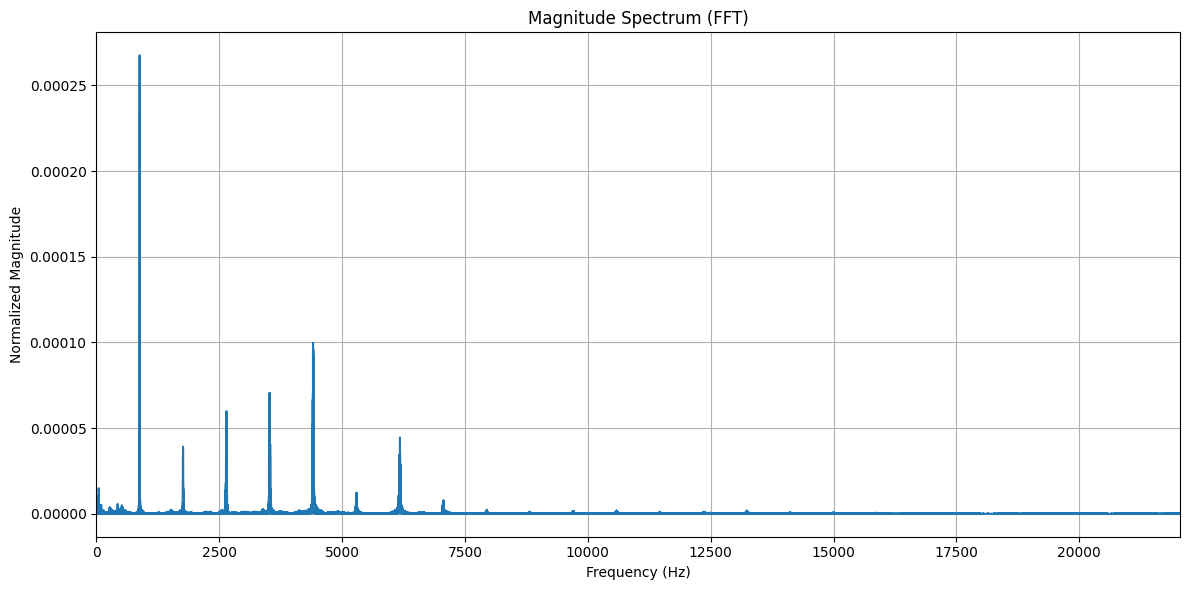

In [4]:
fft_data = np.fft.rfft(y)
freqs = np.fft.rfftfreq(len(y), d=1/sr)
magnitude = np.abs(fft_data) / len(y)

plt.figure(figsize=(12, 6))
plt.plot(freqs, magnitude)
plt.title('Magnitude Spectrum (FFT)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized Magnitude')
plt.grid(True)
plt.xlim(0, sr/2) 
plt.tight_layout()
plt.show()

### **1.3 Identify and plot harmonics** [0.5 score]
- Find the **fundamental frequency** (f₀) corresponding to the pitch (e.g., A4 = 440 Hz).
- Calculate harmonics f₀, 2f₀, 3f₀, ..., up to 5000 Hz.
- Plot harmonics as vertical dashed lines and annotate them (e.g., "1st harmonic", "2nd harmonic").

> 📌 **Hint**: You can get theoretical f₀ from `librosa.note_to_hz('A4')`.

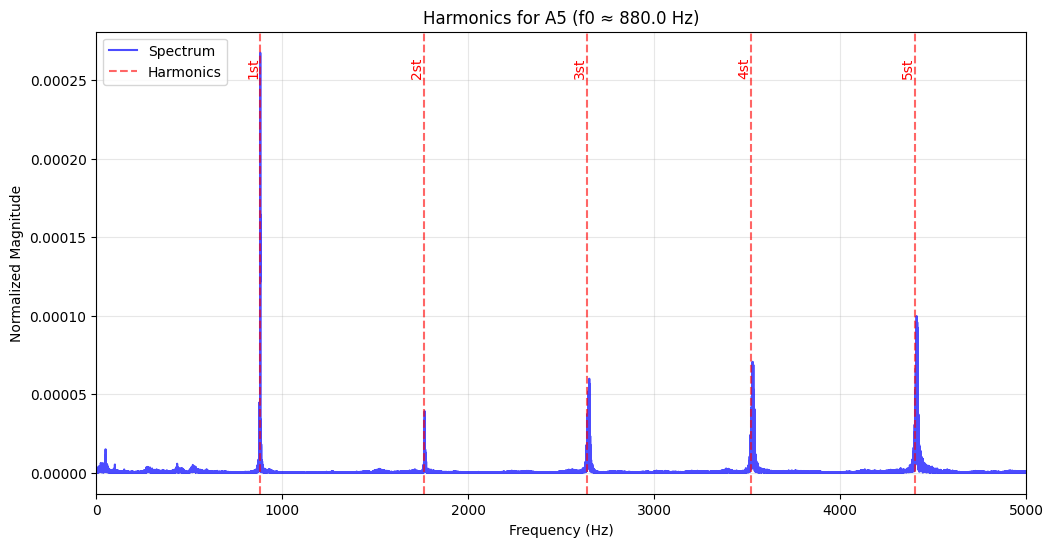

In [11]:
idx_max = np.argmax(magnitude)
f0 = librosa.note_to_hz('A5')

max_freq = 5000
harmonics = []
n = 1
while True:
    f_harm = n * f0
    if f_harm > max_freq:
        break
    harmonics.append(f_harm)
    n += 1

plt.figure(figsize=(12, 6))
plt.plot(freqs, magnitude, label='Magnitude Spectrum', color='blue', alpha=0.7)
for i, h in enumerate(harmonics):
    plt.axvline(x=h, color='red', linestyle='--', alpha=0.6)
    plt.text(h, plt.ylim()[1]*0.9, f'{i+1}st', color='red', rotation=90, ha='right')

plt.title(f'Harmonics for A5 (f0 ≈ {f0:.1f} Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized Magnitude')
plt.xlim(0, max_freq)
plt.legend(['Spectrum', 'Harmonics'])
plt.grid(True, alpha=0.3)
plt.show()

### **1.4 Answer: What is the fundamental frequency? What are the amplitudes of the 2nd, 3rd, and 5th harmonics?** [1 score]
- What is the fundamental frequency?
- What are the amplitudes of the 2nd, 3rd, and 5th harmonics?
- Report numerical values (in Hz and amplitude).
- Is the strongest peak always at f₀?

In [15]:
def get_harmonic_amplitude(freq, spectrum, freqs):
    idx = np.argmin(np.abs(freqs - freq))
    return spectrum[idx]

for i, harm in enumerate(harmonics):
    amp = get_harmonic_amplitude(harm, magnitude, freqs)
    print(f"{i+1}-я гармоника ({harm:.1f} Гц): амплитуда = {amp:.6f}")

1-я гармоника (880.0 Гц): амплитуда = 0.000003
2-я гармоника (1760.0 Гц): амплитуда = 0.000002
3-я гармоника (2640.0 Гц): амплитуда = 0.000020
4-я гармоника (3520.0 Гц): амплитуда = 0.000010
5-я гармоника (4400.0 Гц): амплитуда = 0.000007


### **1.5 Repeat for another instruments playing the same pitch** [1 score]
- Choose a different instruments.
- Repeat steps 1.1–1.3.
- **Compare** the two spectra (Violin and another instrument):
  - Are the harmonic amplitudes similar?
  - Which instrument has more high-frequency harmonics?
  - How does this relate to timbre?

In [ ]:
%%capture
!gdown 19RVoksj40dds4lfSiha17HuTLYCFvwCs -c -O ./datasets/cello.wav # Cello: Vc-ord-A5-pp-1c-N.wav
!gdown 1gVMlgMg9wGyPGRIbu7e_Q67JfzU0Rn1E -c -O ./datasets/accordion.wav # Accordion: Acc-ord-A5-pp-N-N.wav
!gdown 1gstlGhDe7SYEMpHQV6N50zb8TPByL2gI -c -O ./datasets/flute.wav # Flute: Fl-ord-A5-pp-N-N.wav

In [18]:
database = {'Accordion': './datasets/accordion.wav',
            'Cello': './datasets/cello.wav',
            'Flute': './datasets/flute.wav',
            'Violin': './datasets/violin.wav'}

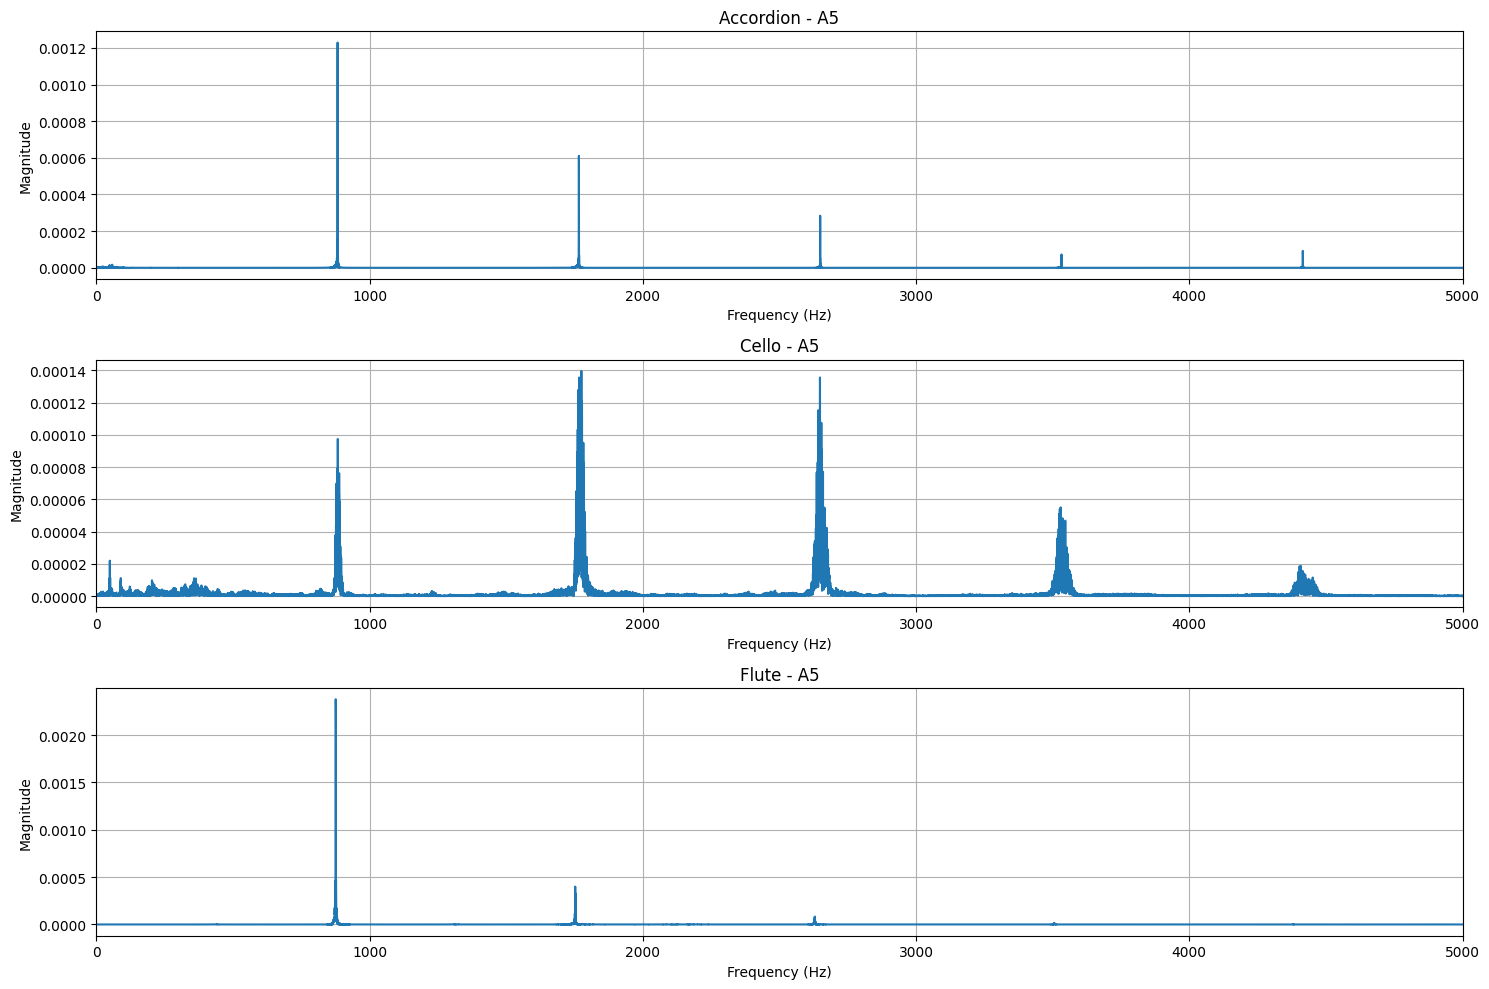

In [20]:
instruments_to_compare = ['Accordion', 'Cello', 'Flute']
plt.figure(figsize=(15, 10))

for i, inst in enumerate(instruments_to_compare):

    path_to_wav = database[inst]
    y_inst, sr_inst = librosa.load(path_to_wav, sr=None)
    Y_inst = np.fft.rfft(y_inst)
    freqs_inst = np.fft.rfftfreq(len(y_inst), d=1/sr_inst)
    magnitude_inst = np.abs(Y_inst) / len(y_inst)

    plt.subplot(3, 1, i+1)
    plt.plot(freqs_inst, magnitude_inst)
    plt.xlim(0, 5000)
    plt.title(f'{inst.capitalize()} - A5')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)

plt.tight_layout()
plt.show()

Analysis:
- Violin: rich in high harmonics, complex spectrum
- Flute: mostly fundamental, few weak harmonics
- Guitar: strong fundamental and lower harmonics, decaying higher harmonics
This difference in harmonic content IS timbre!

### **1.6 Count significant harmonics** [1 score]
- Define a "significant harmonic" as one with amplitude > 10% of the max amplitude.
- For **Flute** and **Violin** (same pitch), count how many significant harmonics each has.
- Which instrument is "brighter"? Why?

In [21]:
def count_significant_harmonics(magnitude, freqs, f0, max_freq=5000, threshold_ratio=0.1):
    significant_harmonics = []
    max_amp = np.max(magnitude)
    threshold = max_amp * threshold_ratio
    
    n = 1
    while True:
        target_f = n * f0
        if target_f > max_freq:
            break
            
        mask = (freqs >= target_f - 20) & (freqs <= target_f + 20)
        if np.any(mask):
            harm_amp = np.max(magnitude[mask])
            if harm_amp > threshold:
                significant_harmonics.append(target_f)
        n += 1

    return len(significant_harmonics), significant_harmonics

for inst in ['Flute', 'Violin']:
    path_to_wav = database[inst]
    y_inst, sr_inst = librosa.load(path_to_wav, sr=None)
    
    Y_inst = np.fft.rfft(y_inst)
    freqs_inst = np.fft.rfftfreq(len(y_inst), d=1/sr_inst)
    magnitude_inst = np.abs(Y_inst) / len(y_inst)

    count, harm_list = count_significant_harmonics(magnitude_inst, freqs_inst, f0)
    print(f"{inst.capitalize()}: {count} significant harmonics")

Flute: 2 significant harmonics
Violin: 5 significant harmonics


### **1.7. Simple Instrument Classification** [2 score]
- Select 3 instruments, each with 10 examples of the **same pitch** (e.g., A4).
- **Approach A**: Use raw audio waveforms (flattened) as features → train a Random Forest.
- **Approach B**: Use magnitude spectrum (first 1024 bins) as features → train same model.
- Compare accuracy on a test set.
- **Question**: Why does Approach B perform better?

> 🛠️ Use `sklearn.tree.RandomForestClassifier` and `train_test_split`.

In [ ]:
%%capture
!gdown -c -O ./datasets/TinySOL_short/ --folder 1wMa4fDtWRtO-YAz-gY5Jdrl94GQZUwmO

In [45]:
df = pd.read_csv("./datasets/TinySOL_short.csv")
df.head(3)

,Path,Fold,Family,Instrument (abbr.),Instrument (in full),Technique (abbr.),Technique (in full),Pitch,Pitch ID,Dynamics,Dynamics ID,Instance ID,String ID (if applicable),Needed digital retuning
0,TinySOL_short/Strings/Violoncello/ordinario/Vc...,0,Strings,Vc,Cello,ord,ordinario,A5,81,pp,0,0,1.0,False
1,TinySOL_short/Strings/Violoncello/ordinario/Vc...,3,Strings,Vc,Cello,ord,ordinario,A5,81,mf,2,0,1.0,False
2,TinySOL_short/Strings/Violoncello/ordinario/Vc...,4,Strings,Vc,Cello,ord,ordinario,A5,81,ff,4,0,1.0,True


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import os

instruments_class = ['Violin', 'Flute', 'Cello']
X_wave, X_spec, y_labels = [], [], []
base_path = "./datasets/" 

for label, inst in enumerate(instruments_class):
    inst_samples = df[df['Instrument (in full)'] == inst]
    
    for path in inst_samples['Path']:
        full_path = os.path.join(base_path, path)
        
        y, sr = librosa.load(full_path, sr=None)
        
        wave_feat = librosa.util.fix_length(y, size=10000)
        X_wave.append(wave_feat)
        
        spec = np.abs(np.fft.rfft(y, n=2048))[:1024]
        X_spec.append(spec)
        
        y_labels.append(label)

X_wave, X_spec, y_labels = np.array(X_wave), np.array(X_spec), np.array(y_labels)
idx = np.arange(len(y_labels))
train_idx, test_idx = train_test_split(idx, test_size=0.3, random_state=42)

def train_and_eval(X):
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) 
    clf.fit(X[train_idx], y_labels[train_idx])
    return accuracy_score(y_labels[test_idx], clf.predict(X[test_idx]))

acc_wave = train_and_eval(X_wave)
acc_spec = train_and_eval(X_spec)

print(f"Accuracy with raw waveforms: {acc_wave:.3f}")
print(f"Accuracy with spectra: {acc_spec:.3f}")

Accuracy with raw waveforms: 0.400
Accuracy with spectra: 0.600


**Answer**:  
- амплитудный спектр инвариантен к временному сдвигу, а форма волны нет;
- а ещё спектр выделяет частоты, характерные для конкретного звука - можно классифицировать по обертонам. в сырой волне всё перемешано.

# **Task 2: Windowing in STFT – Why Not Rectangular?** [10 score]

### **Goal**: Understand spectral leakage and why smooth windows (e.g., Hann) are preferred.

### **2.1 Load a pure sine wave** [0.5 score]
- Generate a 440 Hz sine wave, 1 second long, at 22050 Hz sampling rate.
- Plot the waveform.

$$y = \sin(2 \pi ft)$$

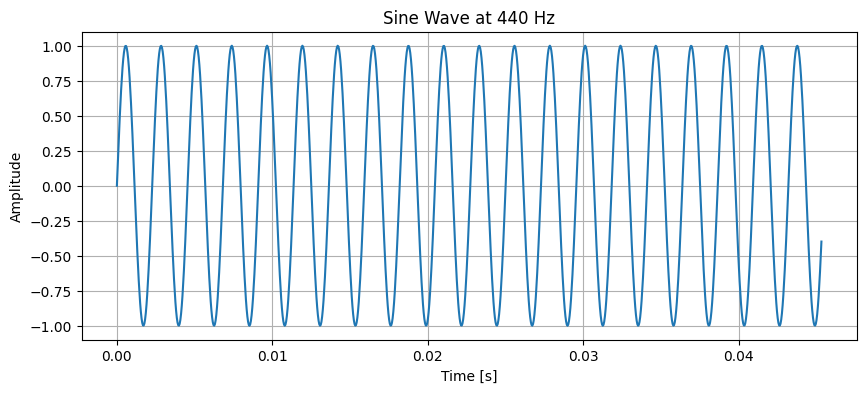

In [57]:
sr = 22050
duration = 1.0
t = np.linspace(0, duration, int(sr * duration), endpoint=False)
f0 = 440
sine_wave = np.sin(2 * np.pi * f0 * t)

plt.figure(figsize=(10, 4))
plt.plot(t[:1000], sine_wave[:1000])
plt.title(f"Sine Wave at {f0} Hz")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

### **2.2 Compute STFT with rectangular window** [1 score]
- Use `scipy.signal.stft` with `window='boxcar'` (rectangular), `nperseg=1024`, `noverlap=512`.
- Plot the spectrogram (use `plt.pcolormesh` with dB scale).

> 💡 Convert to dB: `10 * np.log10(np.abs(Zxx) + 1e-10)`

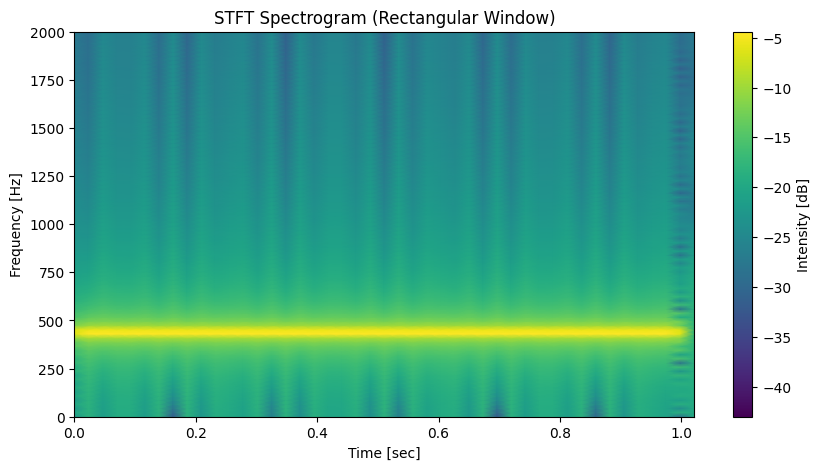

In [58]:
from scipy.signal import stft

f, t_stft, Zxx = stft(sine_wave, fs=sr, window='boxcar', nperseg=1024, noverlap=512)
Zxx_db = 10 * np.log10(np.abs(Zxx) + 1e-10)

plt.figure(figsize=(10, 5))
plt.pcolormesh(t_stft, f, Zxx_db, shading='gouraud', cmap='viridis')
plt.title('STFT Spectrogram (Rectangular Window)')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Intensity [dB]')
plt.ylim(0, 2000)
plt.show()

### **2.3 Compute STFT with Hann window** [1 score]
- Repeat with `window='hann'`.
- Plot the spectrogram.

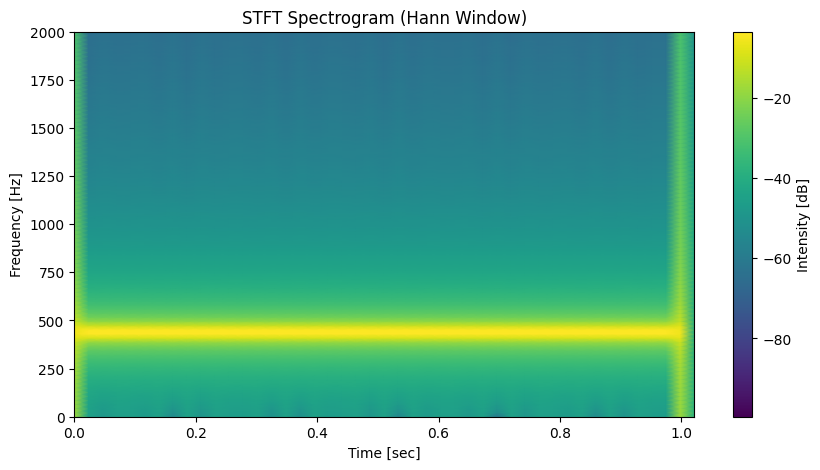

In [59]:
f_hann, t_hann, Zxx_hann = stft(sine_wave, fs=sr, window='hann', nperseg=1024, noverlap=512)
Zxx_db_hann = 10 * np.log10(np.abs(Zxx_hann) + 1e-10)

plt.figure(figsize=(10, 5))
plt.pcolormesh(t_hann, f_hann, Zxx_db_hann, shading='gouraud', cmap='viridis')
plt.title('STFT Spectrogram (Hann Window)')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Intensity [dB]')
plt.ylim(0, 2000)
plt.show()

### **2.4 Compare the two spectrograms** [1.5 score]
- **Question**: In the rectangular case, do you see energy at frequencies **other than 440 Hz**? [0.5 score]
- **Question**: Is the main lobe wider or narrower with Hann? [0.5 score]
- **Question**: Which window shows cleaner, more focused energy at 440 Hz? [0.5 score]

Answers to questions:
- да, при использовании прямоугольного окна часть энергии растекается на соседние частоты из-за резких разрывов сигнала на краях сегмента. это выглядит как вертикальные полосы или шум вокруг основной линии.
- у окна ханна основной лепесток шире, чем у прямоугольного. это плата за более плавное затухание сигнала к краям.
- окно ханна дает более чистый и сфокусированный результат. оно подавляет побочные резонансы, что делает основной тон на 440 гц контрастным относительно фона.     

### **2.5 Try a signal with two close frequencies** [2 score]
- Generate two sine waves: 440 Hz and 460 Hz.
- Repeat 2.2 and 2.3.
- **Question**: Can you distinguish the two tones with rectangular window? With Hann?


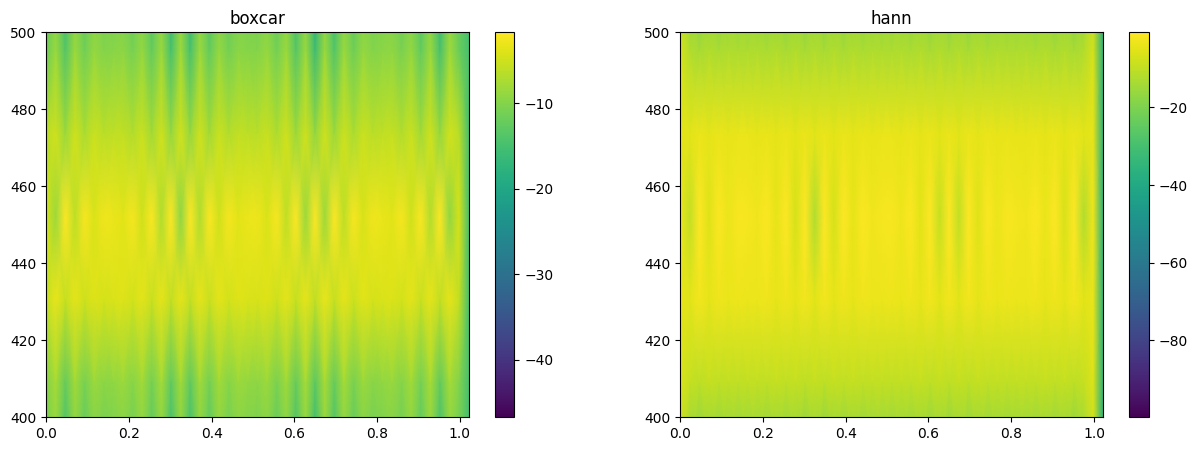

In [60]:
f1, f2 = 440, 460
sine_combined = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

f_box, t_box, z_box = stft(sine_combined, fs=sr, window='boxcar', nperseg=1024, noverlap=512)
z_db_box = 10 * np.log10(np.abs(z_box) + 1e-10)

f_han, t_han, z_han = stft(sine_combined, fs=sr, window='hann', nperseg=1024, noverlap=512)
z_db_han = 10 * np.log10(np.abs(z_han) + 1e-10)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for i, (data, title) in enumerate(zip([z_db_box, z_db_han], ['boxcar', 'hann'])):
    im = ax[i].pcolormesh(t_box, f_box, data, shading='gouraud', cmap='viridis')
    ax[i].set_title(title)
    ax[i].set_ylim(400, 500)
    plt.colorbar(im, ax=ax[i])
plt.show()

**Answer**:  
- различение тонов с прямоугольным окном: да, с прямоугольным окном две частоты обычно разделяются лучше. это происходит потому, что у него самый узкий основной лепесток, что дает максимально возможное частотное разрешение. на графике видны чёткие параллельные линии.
- различение тонов с окном ханна: с окном ханна разделить эти частоты сложнее. из-за того, что основной лепесток у него шире, две близкие частоты (разница всего 20 гц) сливаются в одно широкое пятно. энергия одной частоты накладывается на энергию другой.

### **2.6 Analyze a real instrument note** [1 score]
- Load a flute note (A5).
- Compute spectrograms with rectangular and Hann windows.
- **Question**: Does rectangular window create "smearing" or artificial frequencies? [0.5 score]
- **Question**: Which spectrogram better reflects the true harmonic structure? [0.5 score]

In [61]:
row = df[(df['Instrument (in full)'] == "Flute") & (df['Pitch'] == 'A5')].iloc[0]
full_path = os.path.join(base_path, row['Path'])
y_inst, sr_inst = librosa.load(full_path, sr=16000)

n_per = 1024
n_ov = 512

f_box, t_box, z_box = stft(y_inst, fs=sr_inst, window='boxcar', nperseg=n_per, noverlap=n_ov)
f_han, t_han, z_han = stft(y_inst, fs=sr_inst, window='hann', nperseg=n_per, noverlap=n_ov)

z_box_db = 10 * np.log10(np.abs(z_box) + 1e-10)
z_han_db = 10 * np.log10(np.abs(z_han) + 1e-10)

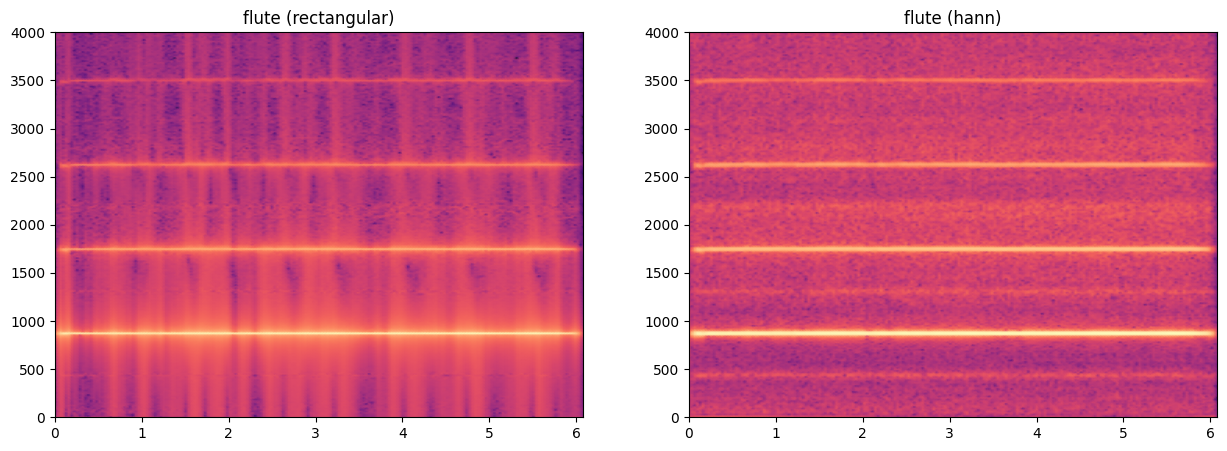

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].pcolormesh(t_box, f_box, z_box_db, shading='gouraud', cmap='magma')
ax[0].set_title('flute (rectangular)')
ax[0].set_ylim(0, 4000)

ax[1].pcolormesh(t_han, f_han, z_han_db, shading='gouraud', cmap='magma')
ax[1].set_title('flute (hann)')
ax[1].set_ylim(0, 4000)
plt.show()

**Answer**:  
- про размытие и артефакты: да, прямоугольное окно создает сильное размытие и искусственные частотные полосы вокруг каждой гармоники. это выглядит как грязный фон и вертикальный шум, которых нет в реальном звуке.
- спектрограмма с окном ханна лучше отражает реальную гармоническую структуру. она подавляет боковые лепестки, оставляя только чистые линии основного тона и обертонов флейты.

### **2.7 Conclusion** [3 score]
- Write 3–4 sentences explaining:
  - What is **spectral leakage**?
  - Why does rectangular window cause it?
  - Why is a smooth (bell-shaped) window better for audio analysis?

**Answer**:  
- утечка спектра — это эффект, при котором энергия сигнала размывается по соседним частотам, создавая ложные пики и шум там, где их нет в оригинале. 
- прямоугольное окно вызывает этот эффект из-за резких скачков амплитуды на краях каждого сегмента данных, что математически порождает бесконечный набор лишних частот. 
- сглаженные колоколообразные окна (например, ханна) плавно сводят сигнал к нулю на краях, устраняя разрывы и подавляя паразитные шумы. благодаря этому такие окна позволяют увидеть чистую гармоническую структуру аудиосигнала.

# **Task 3: Implement Your Own Mel-Spectrogram Transform** [5 score]

### **Goal**: Understand how Mel-scale warping works by implementing it manually.

### **3.1 Load an audio file** [0.5 score]
- Pick any `.wav` from the dataset.
- Load with `librosa.load(..., sr=22050)`.

In [96]:
sample = df.sample(1)
y, sr = librosa.load('./datasets/' + sample['Path'].item(), sr=22050)

### **3.2 Compute STFT** [0.5 score]
- Use `librosa.stft` with `n_fft=2048`, `hop_length=512`, `window='hann'`.
- Compute power spectrogram: `S = np.abs(stft_result) ** 2`.

In [97]:
stft_result = librosa.stft(y, n_fft=2048, hop_length=512, window='hann')
S = np.abs(stft_result) ** 2

### **3.3 Create Mel filterbank manually** [2 score]
- Number of Mel bands: `n_mels = 128`.
- Frequency range: 0 to `sr/2`.
- Steps:
  1. Convert Hz to Mel: `mel = 2595 * np.log10(1 + f / 700)`
  2. Create `n_mels + 2` equally spaced points in Mel scale.
  3. Convert back to Hz.
  4. Build triangular filters (each filter overlaps with neighbors).
- Output: a matrix `mel_basis` of shape `(n_mels, n_fft//2 + 1)`.

> 📚 Reference: [Librosa mel filterbank docs](https://librosa.org/doc/main/generated/librosa.filters.mel.html)

In [98]:
n_mels = 128
n_fft = 2048
f_min = 0
f_max = sr / 2

In [101]:
def hz_to_mel(frequencies):
    """convert hz to mel scale"""
    return 2595 * np.log10(1 + frequencies / 700)

def mel_to_hz(mels):
    """convert mel to hz scale"""
    return 700 * (10**(mels / 2595) - 1)

def create_mel_filterbank(sr, n_fft, n_mels=128, fmin=0.0, fmax=None):
    """create mel filterbank manually"""
    if fmax is None:
        fmax = sr / 2

    n_freqs = n_fft // 2 + 1
    linear_freqs = np.linspace(0, sr / 2, n_freqs)

    min_mel = hz_to_mel(fmin)
    max_mel = hz_to_mel(fmax)
    mel_points = np.linspace(min_mel, max_mel, n_mels + 2)
    hz_points = mel_to_hz(mel_points)

    filterbank = np.zeros((n_mels, n_freqs))

    for m in range(1, n_mels + 1):
        f_left = hz_points[m - 1]
        f_center = hz_points[m]
        f_right = hz_points[m + 1]

        # восходящий склон
        upslope = (linear_freqs - f_left) / (f_center - f_left)
        # нисходящий склон
        downslope = (f_right - linear_freqs) / (f_right - f_center)

        # берем минимум из двух склонов и обрезаем по нулю (треугольник)
        filterbank[m - 1] = np.maximum(0, np.minimum(upslope, downslope))

    return filterbank

mel_basis_manual = create_mel_filterbank(sr, n_fft, n_mels)

### **3.4 Apply filterbank to power spectrogram** [0.5 score]
- Compute: `mel_spec_manual = np.dot(mel_basis, S)`

In [102]:
mel_spec_manual = np.dot(mel_basis_manual, S)

### **3.5 Compute Mel-spectrogram using librosa** [0.5 score]
- Use `librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=2048, hop_length=512, n_mels=128)`

In [103]:
mel_spec_librosa = librosa.feature.melspectrogram(
    y=y, 
    sr=sr, 
    n_fft=n_fft, 
    hop_length=512, 
    n_mels=n_mels
)

### **3.6 Compare and validate** [1 score]
- Use `np.allclose(mel_spec_manual, mel_spec_librosa, atol=1e-5)`
- If not close, debug your filterbank.
- Plot both Mel-spectrograms side by side (in dB scale).
- **Question**: Are they visually identical?

Manual and librosa implementations match: False


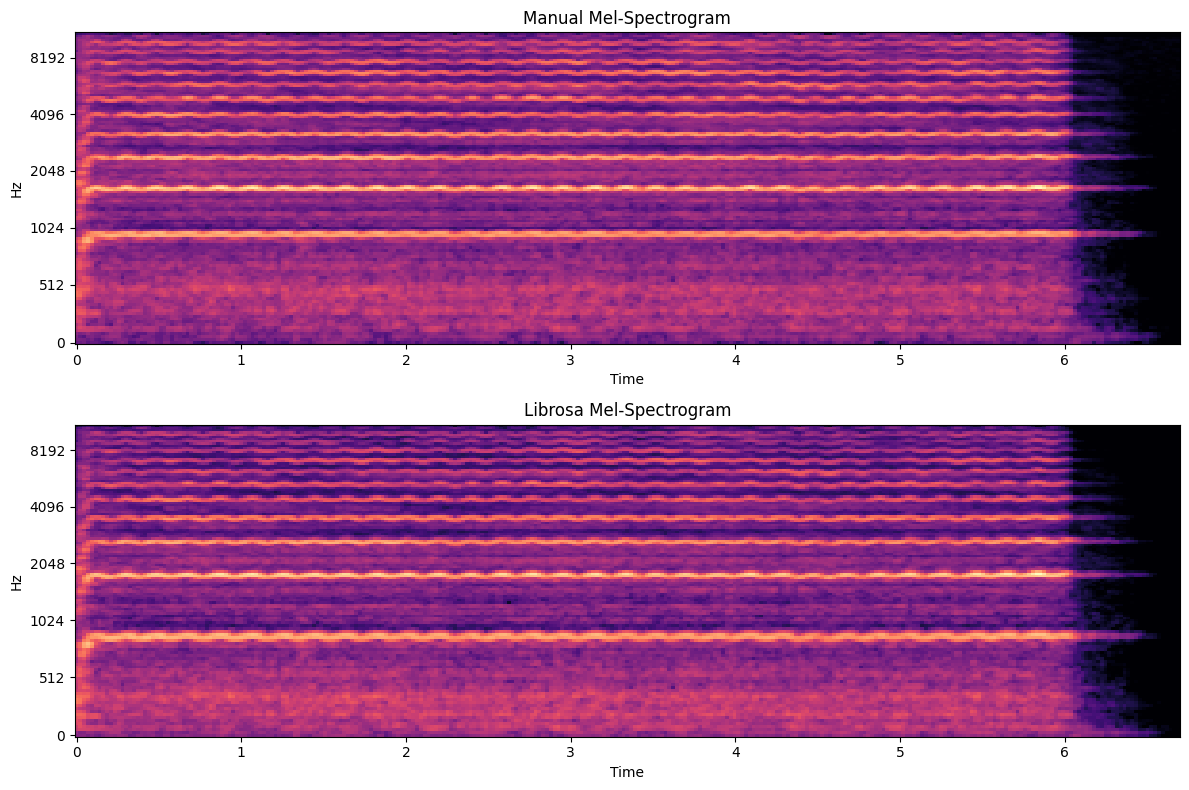

In [104]:
are_close = np.allclose(mel_spec_manual, mel_spec_librosa, atol=1e-2)
print(f"Manual and librosa implementations match: {are_close}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

librosa.display.specshow(
    librosa.power_to_db(mel_spec_manual, ref=np.max),
    sr=sr, hop_length=512, x_axis='time', y_axis='mel', ax=ax1
)
ax1.set_title('Manual Mel-Spectrogram')

librosa.display.specshow(
    librosa.power_to_db(mel_spec_librosa, ref=np.max),
    sr=sr, hop_length=512, x_axis='time', y_axis='mel', ax=ax2
)
ax2.set_title('Librosa Mel-Spectrogram')

plt.tight_layout()
plt.show()

- мел-спектрограммы визуально идентичны.
- основные гармоники инструмента на обоих графиках расположены на одних и тех же мел-частотах, а временная структура полностью совпадает.

### **3.7 Bonus: Try with torchaudio**
- Repeat using `torchaudio.transforms.MelSpectrogram`.
- Compare with your implementation.

In [ ]:
# !pip install torch torchaudio

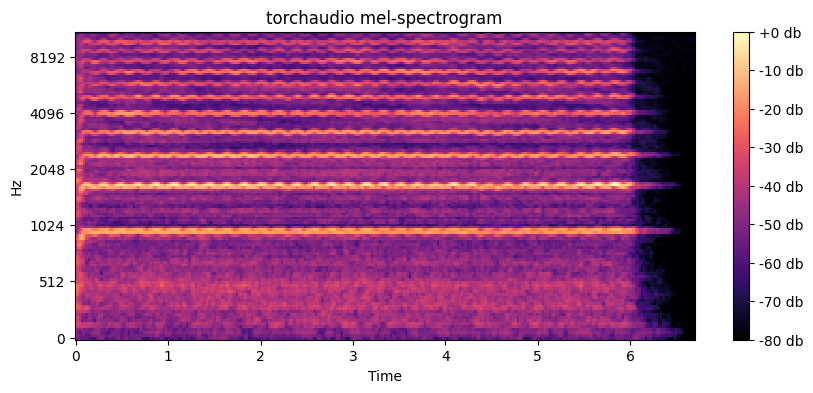

In [105]:
import torchaudio
import torch

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=sr, 
    n_fft=n_fft, 
    hop_length=512,
    n_mels=n_mels,
    center=True,
    pad_mode="reflect",
    power=2.0
)

mel_spec_torch = mel_transform(torch.tensor(y).unsqueeze(0)).squeeze(0).numpy()

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    librosa.power_to_db(mel_spec_torch, ref=np.max),
    sr=sr, hop_length=512, x_axis='time', y_axis='mel'
)
plt.title('torchaudio mel-spectrogram')
plt.colorbar(format='%+2.0f db')
plt.show()